<a href="https://colab.research.google.com/github/msolowes-star/DI-Bootcamp/blob/main/Week5MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

Load the Data Set

In [11]:
import pandas as pd

df = pd.read_excel("/US Superstore data.xls")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
# Check the dataset
print(df.shape)
df.info()

# Check for missing values
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Convert dates to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Create additional date columns
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()

# Verify everything looks good
df.head()

(9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Catego

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October


Exploration and preprocessing of the dataset

In [14]:
print("Dataset shape:", df.shape)
print()

df.info()

Dataset shape: (9994, 23)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        

In [16]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [17]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [18]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    errors="coerce"
)

In [19]:
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

In [20]:
df = df.dropna(
    subset=[
        "Order Date",
        "Customer ID",
        "State",
        "City",
        "Sales",
        "Profit"
    ]
).copy()

In [21]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

In [22]:
print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (9994, 25)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Year-Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,2015-10


Which states have the most sales?

In [23]:
state_performance = (
    df.groupby("State", as_index=False)
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order ID", "nunique")
      )
      .sort_values("Total_Sales", ascending=False)
)

state_performance.head(10)

,State,Total_Sales,Total_Profit,Total_Orders
3,California,457687.6315,76381.3871,1021
30,New York,310876.2710,74038.5486,562
41,Texas,170188.0458,-25729.3563,487
45,Washington,138641.2700,33402.6517,256
36,Pennsylvania,116511.9140,-15559.9603,288
8,Florida,89473.7080,-3399.3017,200
11,Illinois,80166.1010,-12607.8870,276
33,Ohio,78258.1360,-16971.3766,236
20,Michigan,76269.6140,24463.1876,117
44,Virginia,70636.7200,18597.9504,115


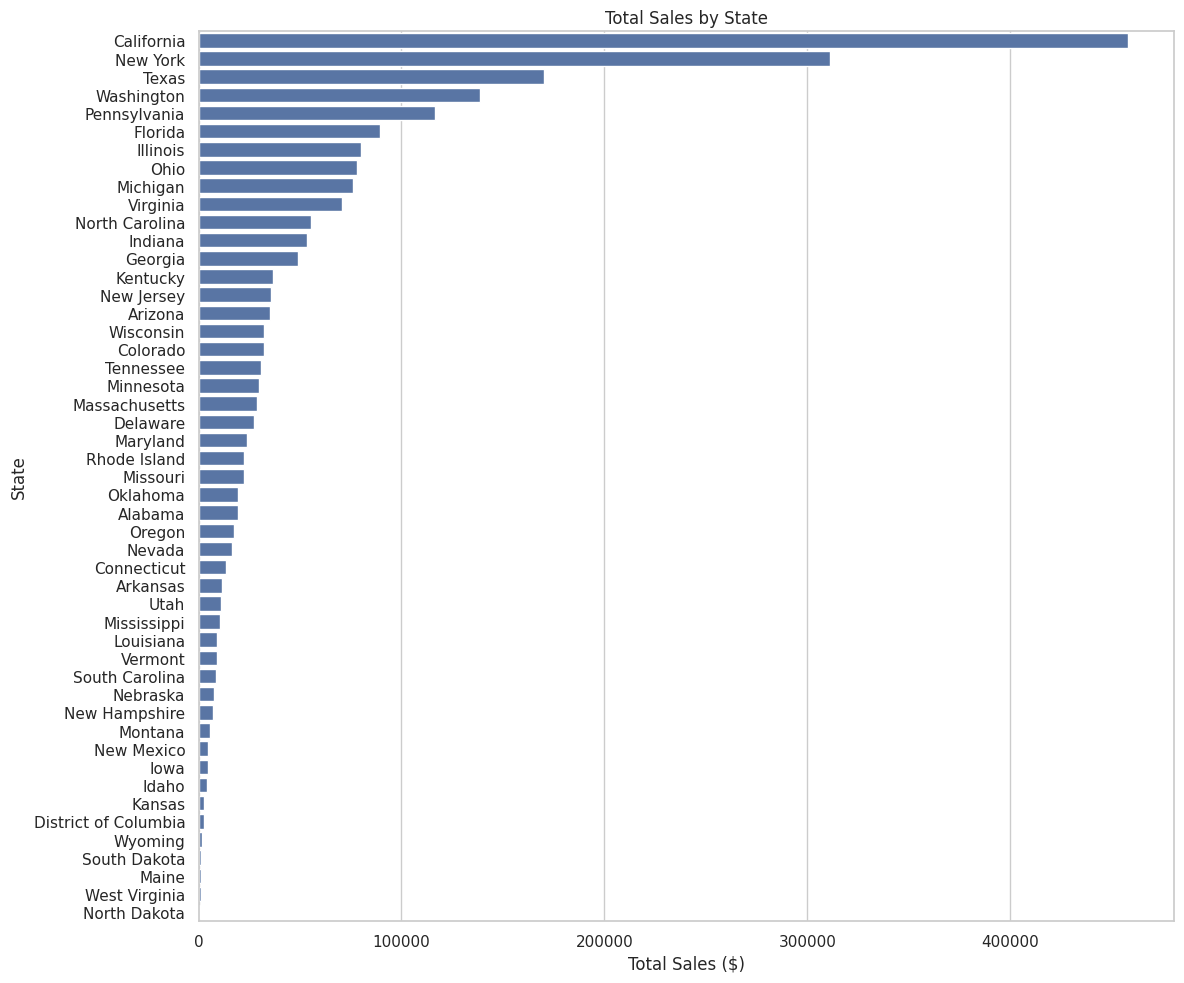

In [25]:
plt.figure(figsize=(12, 10))

sns.barplot(
    data=state_performance,
    x="Total_Sales",
    y="State"
)

plt.title("Total Sales by State")
plt.xlabel("Total Sales ($)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

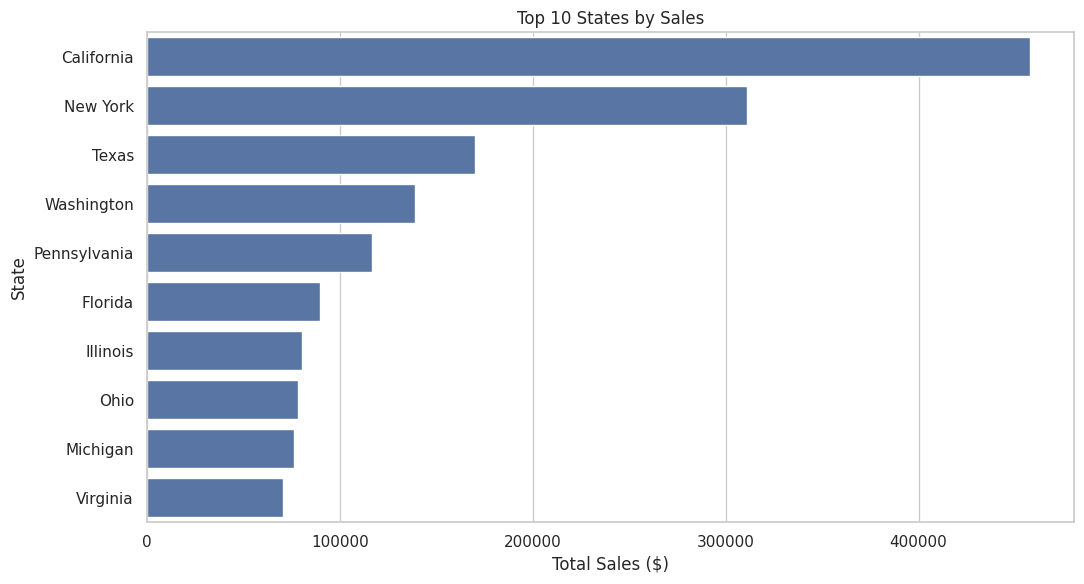

In [26]:
top_10_states_sales = state_performance.head(10)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_10_states_sales,
    x="Total_Sales",
    y="State"
)

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [27]:
top_10_states_sales[
    ["State", "Total_Sales", "Total_Profit"]
].style.format({
    "Total_Sales": "${:,.2f}",
    "Total_Profit": "${:,.2f}"
})

,State,Total_Sales,Total_Profit
3,California,"$457,687.63","$76,381.39"
30,New York,"$310,876.27","$74,038.55"
41,Texas,"$170,188.05","$-25,729.36"
45,Washington,"$138,641.27","$33,402.65"
36,Pennsylvania,"$116,511.91","$-15,559.96"
8,Florida,"$89,473.71","$-3,399.30"
11,Illinois,"$80,166.10","$-12,607.89"
33,Ohio,"$78,258.14","$-16,971.38"
20,Michigan,"$76,269.61","$24,463.19"
44,Virginia,"$70,636.72","$18,597.95"


Summary of Data

California, New York, Texas, and Pennsylvania are the strongest states by total sales. These states should receive significant marketing attention because they already have large customer bases and high revenue.

New York and California Sales and Profit

In [28]:
ny_ca_comparison = (
    df[df["State"].isin(["New York", "California"])]
    .groupby("State", as_index=False)
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Number_of_Orders=("Order ID", "nunique"),
        Number_of_Customers=("Customer ID", "nunique")
    )
)

ny_ca_comparison

,State,Total_Sales,Total_Profit,Number_of_Orders,Number_of_Customers
0,California,457687.6315,76381.3871,1021,577
1,New York,310876.2710,74038.5486,562,415


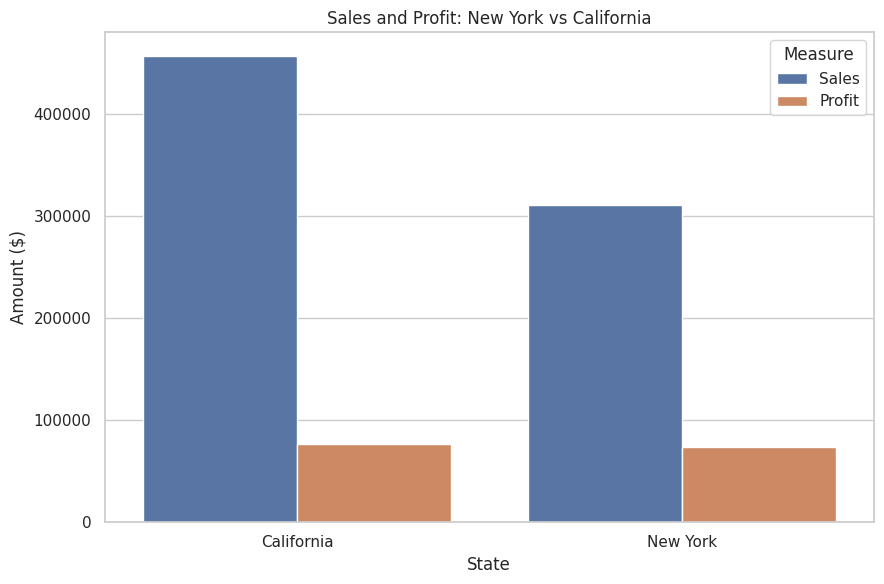

In [29]:
comparison_long = ny_ca_comparison.melt(
    id_vars="State",
    value_vars=["Total_Sales", "Total_Profit"],
    var_name="Measure",
    value_name="Amount"
)

comparison_long["Measure"] = comparison_long["Measure"].replace({
    "Total_Sales": "Sales",
    "Total_Profit": "Profit"
})

plt.figure(figsize=(9, 6))

sns.barplot(
    data=comparison_long,
    x="State",
    y="Amount",
    hue="Measure"
)

plt.title("Sales and Profit: New York vs California")
plt.xlabel("State")
plt.ylabel("Amount ($)")
plt.tight_layout()
plt.show()

In [30]:
ny_ca_comparison["Profit_Margin"] = (
    ny_ca_comparison["Total_Profit"] /
    ny_ca_comparison["Total_Sales"] * 100
)

ny_ca_comparison.style.format({
    "Total_Sales": "${:,.2f}",
    "Total_Profit": "${:,.2f}",
    "Profit_Margin": "{:.2f}%"
})

,State,Total_Sales,Total_Profit,Number_of_Orders,Number_of_Customers,Profit_Margin
0,California,"$457,687.63","$76,381.39",1021,577,16.69%
1,New York,"$310,876.27","$74,038.55",562,415,23.82%


In [31]:
comparison_indexed = ny_ca_comparison.set_index("State")

sales_difference = (
    comparison_indexed.loc["California", "Total_Sales"] -
    comparison_indexed.loc["New York", "Total_Sales"]
)

profit_difference = (
    comparison_indexed.loc["California", "Total_Profit"] -
    comparison_indexed.loc["New York", "Total_Profit"]
)

print(f"California minus New York sales: ${sales_difference:,.2f}")
print(f"California minus New York profit: ${profit_difference:,.2f}")

California minus New York sales: $146,811.36
California minus New York profit: $2,342.84


Who is an outstanding customer in New York?

In [32]:
ny_customers = (
    df[df["State"] == "New York"]
    .groupby(
        ["Customer ID", "Customer Name"],
        as_index=False
    )
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Number_of_Orders=("Order ID", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
)

ny_customers.head(10)

,Customer ID,Customer Name,Total_Sales,Total_Profit,Number_of_Orders,Total_Quantity
380,TA-21385,Tom Ashbrook,13723.498,4599.2073,2,22
309,PF-19120,Peter Fuller,7678.228,543.2819,1,40
373,SV-20365,Seth Vernon,7359.918,1571.7964,1,52
387,TB-21400,Tom Boeckenhauer,6999.960,2239.9872,1,4
169,GT-14710,Greg Tran,6712.744,774.7935,4,28
402,TS-21370,Todd Sumrall,6492.314,1574.9714,2,17
228,KD-16270,Karen Daniels,6241.282,2283.0463,2,22
230,KD-16495,Keith Dawkins,5854.194,2510.8903,2,18
255,LW-17215,Luke Weiss,5048.186,773.1004,3,25
74,CJ-12010,Caroline Jumper,5012.760,1300.0330,2,33


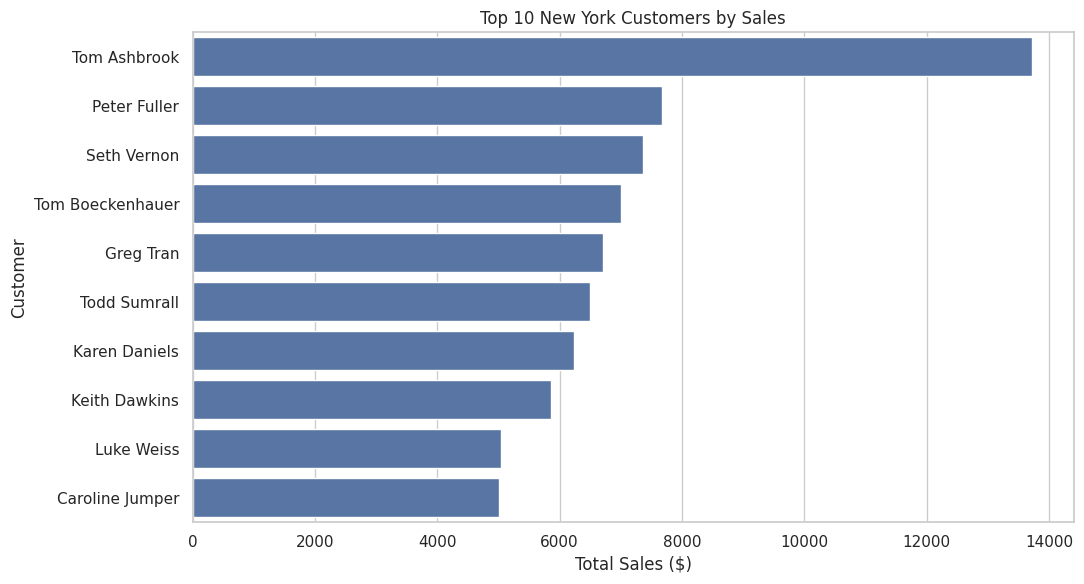

In [33]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=ny_customers.head(10),
    x="Total_Sales",
    y="Customer Name"
)

plt.title("Top 10 New York Customers by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

In [34]:
top_ny_sales_customer = ny_customers.iloc[0]

print("Outstanding New York customer by sales:")
print("Customer:", top_ny_sales_customer["Customer Name"])
print(f"Sales: ${top_ny_sales_customer['Total_Sales']:,.2f}")
print(f"Profit: ${top_ny_sales_customer['Total_Profit']:,.2f}")
print("Orders:", top_ny_sales_customer["Number_of_Orders"])

Outstanding New York customer by sales:
Customer: Tom Ashbrook
Sales: $13,723.50
Profit: $4,599.21
Orders: 2


In [35]:
top_ny_profit_customer = (
    ny_customers
    .sort_values("Total_Profit", ascending=False)
    .iloc[0]
)

print("Outstanding New York customer by profit:")
print("Customer:", top_ny_profit_customer["Customer Name"])
print(f"Sales: ${top_ny_profit_customer['Total_Sales']:,.2f}")
print(f"Profit: ${top_ny_profit_customer['Total_Profit']:,.2f}")
print("Orders:", top_ny_profit_customer["Number_of_Orders"])

Outstanding New York customer by profit:
Customer: Tom Ashbrook
Sales: $13,723.50
Profit: $4,599.21
Orders: 2


Summary of Data:

The outstanding customer can be defined as the customer with the highest sales, although the customer with the highest profit may be more valuable to the business. Both should be considered for loyalty or account-management programs.

Are there differences among states in profitability?

In [36]:
state_profitability = (
    df.groupby("State", as_index=False)
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

state_profitability["Profit_Margin"] = (
    state_profitability["Total_Profit"] /
    state_profitability["Total_Sales"] * 100
)

state_profitability = state_profitability.sort_values(
    "Total_Profit",
    ascending=False
)

state_profitability.head()

,State,Total_Sales,Total_Profit,Profit_Margin
3,California,457687.6315,76381.3871,16.688541
30,New York,310876.2710,74038.5486,23.816082
45,Washington,138641.2700,33402.6517,24.092863
20,Michigan,76269.6140,24463.1876,32.074618
44,Virginia,70636.7200,18597.9504,26.329012


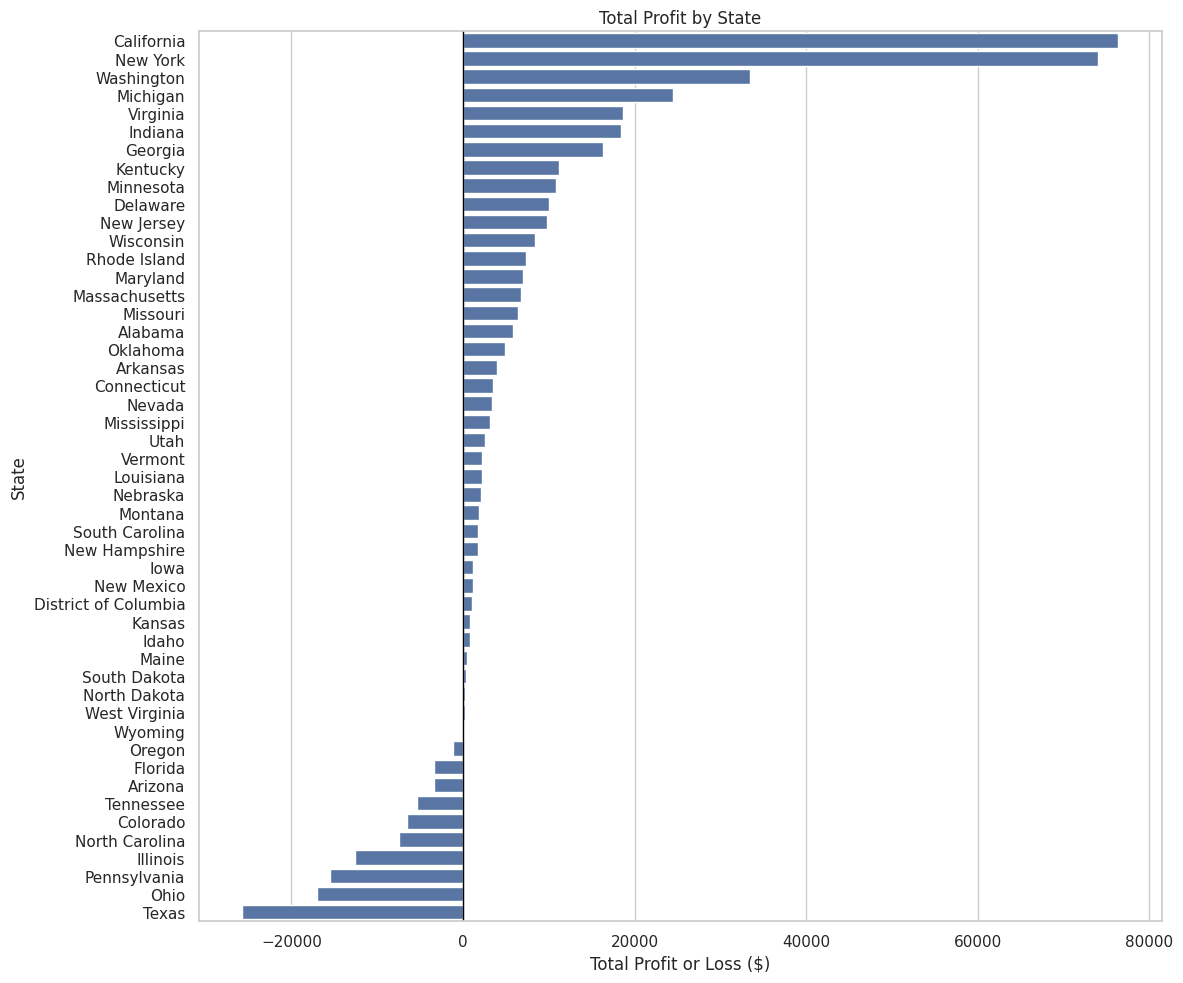

In [37]:
plt.figure(figsize=(12, 10))

sns.barplot(
    data=state_profitability,
    x="Total_Profit",
    y="State"
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Total Profit by State")
plt.xlabel("Total Profit or Loss ($)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [38]:
print("Most profitable states:")

state_profitability.nlargest(
    10,
    "Total_Profit"
)[["State", "Total_Sales", "Total_Profit", "Profit_Margin"]]

Most profitable states:


,State,Total_Sales,Total_Profit,Profit_Margin
3,California,457687.6315,76381.3871,16.688541
30,New York,310876.2710,74038.5486,23.816082
45,Washington,138641.2700,33402.6517,24.092863
20,Michigan,76269.6140,24463.1876,32.074618
44,Virginia,70636.7200,18597.9504,26.329012
12,Indiana,53555.3600,18382.9363,34.325110
9,Georgia,49095.8400,16250.0433,33.098615
15,Kentucky,36591.7500,11199.6966,30.607163
21,Minnesota,29863.1500,10823.1874,36.242618
6,Delaware,27451.0690,9977.3748,36.346034


In [39]:
print("Least profitable states:")

state_profitability.nsmallest(
    10,
    "Total_Profit"
)[["State", "Total_Sales", "Total_Profit", "Profit_Margin"]]

Least profitable states:


,State,Total_Sales,Total_Profit,Profit_Margin
41,Texas,170188.0458,-25729.3563,-15.118192
33,Ohio,78258.1360,-16971.3766,-21.686405
36,Pennsylvania,116511.9140,-15559.9603,-13.354823
11,Illinois,80166.1010,-12607.8870,-15.727205
31,North Carolina,55603.1640,-7490.9122,-13.472097
4,Colorado,32108.1180,-6527.8579,-20.330864
40,Tennessee,30661.8730,-5341.6936,-17.421289
1,Arizona,35282.0010,-3427.9246,-9.715789
8,Florida,89473.7080,-3399.3017,-3.799219
35,Oregon,17431.1500,-1190.4705,-6.829558


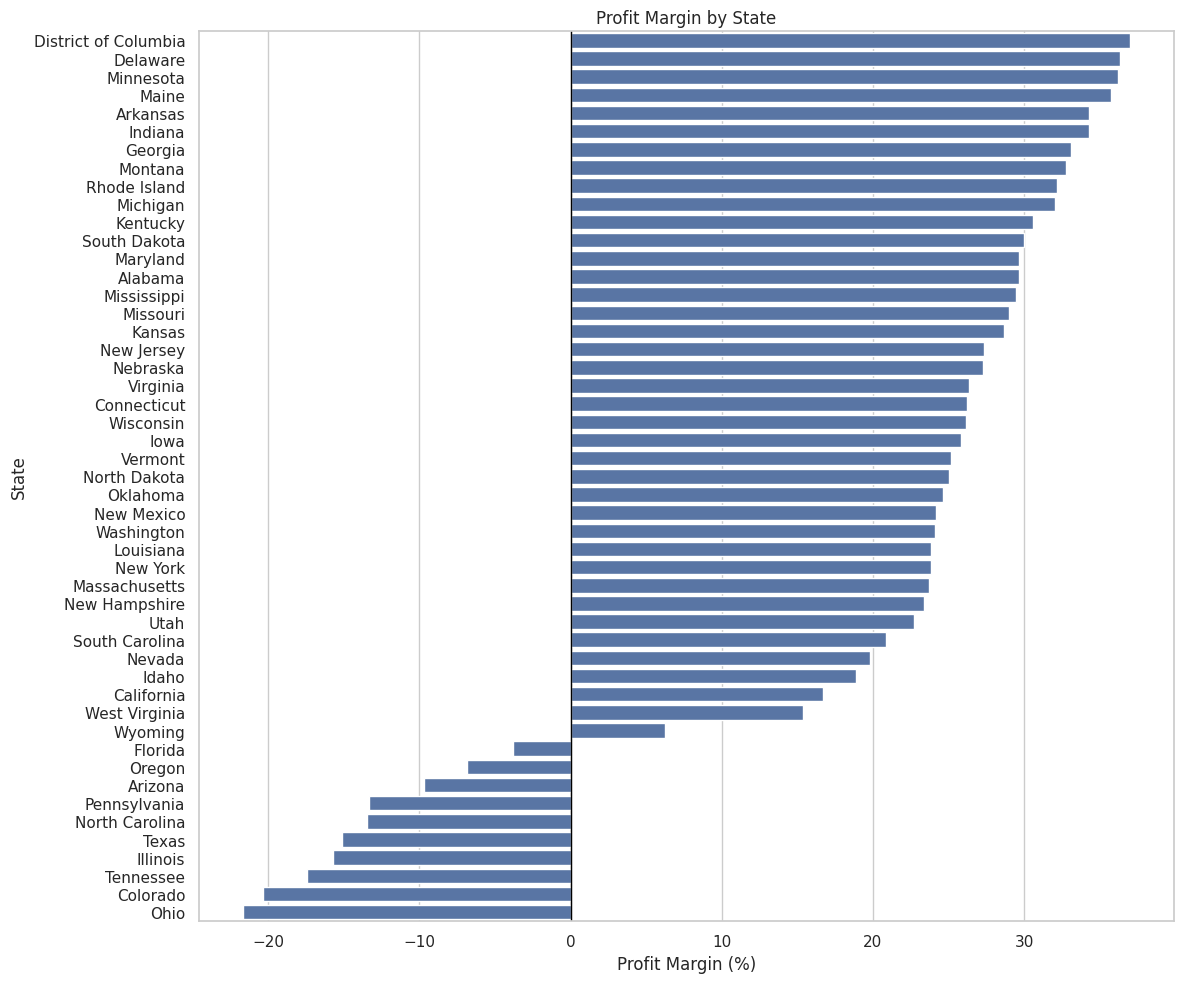

In [40]:
profit_margin_sorted = state_profitability.sort_values(
    "Profit_Margin",
    ascending=False
)

plt.figure(figsize=(12, 10))

sns.barplot(
    data=profit_margin_sorted,
    x="Profit_Margin",
    y="State"
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Profit Margin by State")
plt.xlabel("Profit Margin (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

Summary of Data:

A state may have high sales but low or negative profit. This can happen because of:

Heavy discounts
High shipping or operating costs
Unprofitable product categories
A large number of low-margin orders

Therefore, marketing decisions should not be based on sales alone.  As an example, Texas has has one of the highest sales, but the lowest profit margin.  

Pareto Principle: Do 20% of customers generate 80% of profit?

In [41]:
customer_profit = (
    df.groupby(
        ["Customer ID", "Customer Name"],
        as_index=False
    )
    .agg(
        Total_Profit=("Profit", "sum"),
        Total_Sales=("Sales", "sum")
    )
    .sort_values("Total_Profit", ascending=False)
)

customer_profit.head()

,Customer ID,Customer Name,Total_Profit,Total_Sales
741,TC-20980,Tamara Chand,8981.3239,19052.218
621,RB-19360,Raymond Buch,6976.0959,15117.339
669,SC-20095,Sanjit Chand,5757.4119,14142.334
327,HL-15040,Hunter Lopez,5622.4292,12873.298
6,AB-10105,Adrian Barton,5444.8055,14473.571


In [42]:
profitable_customers = customer_profit[
    customer_profit["Total_Profit"] > 0
].copy()

loss_customers = customer_profit[
    customer_profit["Total_Profit"] <= 0
].copy()

print("Profitable customers:", len(profitable_customers))
print("Customers with zero or negative profit:", len(loss_customers))

Profitable customers: 638
Customers with zero or negative profit: 155


In [43]:
profitable_customers = profitable_customers.sort_values(
    "Total_Profit",
    ascending=False
).reset_index(drop=True)

profitable_customers["Cumulative_Profit"] = (
    profitable_customers["Total_Profit"].cumsum()
)

profitable_customers["Cumulative_Profit_Percentage"] = (
    profitable_customers["Cumulative_Profit"] /
    profitable_customers["Total_Profit"].sum() * 100
)

profitable_customers["Customer_Percentage"] = (
    np.arange(1, len(profitable_customers) + 1) /
    len(profitable_customers) * 100
)

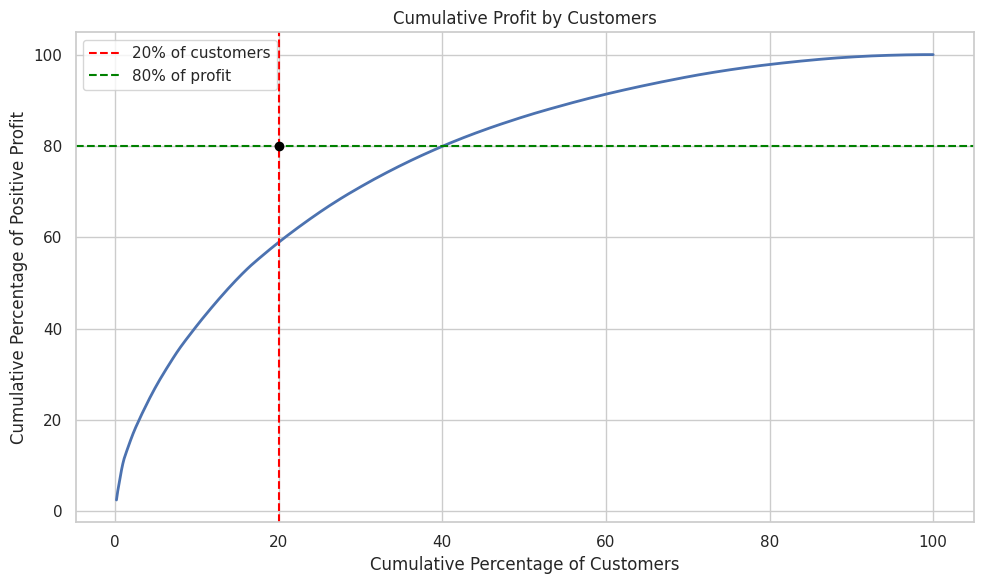

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    profitable_customers["Customer_Percentage"],
    profitable_customers["Cumulative_Profit_Percentage"],
    linewidth=2
)

plt.axvline(
    20,
    color="red",
    linestyle="--",
    label="20% of customers"
)

plt.axhline(
    80,
    color="green",
    linestyle="--",
    label="80% of profit"
)

plt.scatter(
    20,
    80,
    color="black",
    zorder=5
)

plt.title("Cumulative Profit by Customers")
plt.xlabel("Cumulative Percentage of Customers")
plt.ylabel("Cumulative Percentage of Positive Profit")
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
top_20_count_profit = int(
    np.ceil(len(profitable_customers) * 0.20)
)

top_20_profit_share = (
    profitable_customers
    .head(top_20_count_profit)["Total_Profit"]
    .sum() /
    profitable_customers["Total_Profit"].sum() * 100
)

print(
    f"The top 20% of profitable customers generate "
    f"{top_20_profit_share:.2f}% of positive customer profit."
)

The top 20% of profitable customers generate 59.02% of positive customer profit.


In [46]:
customers_to_80_profit = (
    profitable_customers[
        profitable_customers["Cumulative_Profit_Percentage"] >= 80
    ]
    .iloc[0]
)

print(
    f"It takes approximately "
    f"{customers_to_80_profit['Customer_Percentage']:.2f}% "
    f"of profitable customers to generate 80% of positive profit."
)

It takes approximately 40.13% of profitable customers to generate 80% of positive profit.


In [47]:
if top_20_profit_share >= 80:
    print("The Pareto Principle applies to customer profit.")
else:
    print("The exact 80/20 rule does not apply to customer profit.")
    print("However, profit may still be concentrated among a relatively small group.")

The exact 80/20 rule does not apply to customer profit.
However, profit may still be concentrated among a relatively small group.


Top 20 cities by sales and profit

In [48]:
city_performance = (
    df.groupby(["City", "State"], as_index=False)
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Number_of_Orders=("Order ID", "nunique"),
          Number_of_Customers=("Customer ID", "nunique")
      )
)

city_performance["Profit_Margin"] = (
    city_performance["Total_Profit"] /
    city_performance["Total_Sales"] * 100
)

city_performance["City_State"] = (
    city_performance["City"] +
    ", " +
    city_performance["State"]
)

In [49]:
top_20_cities_sales = (
    city_performance
    .sort_values("Total_Sales", ascending=False)
    .head(20)
)

top_20_cities_sales[
    [
        "City_State",
        "Total_Sales",
        "Total_Profit",
        "Profit_Margin"
    ]
]

,City_State,Total_Sales,Total_Profit,Profit_Margin
380,"New York City, New York",256368.1610,62036.9837,24.198396
312,"Los Angeles, California",175851.3410,30440.7579,17.310507
517,"Seattle, Washington",119540.7420,29156.0967,24.390092
503,"San Francisco, California",112669.0920,17507.3854,15.538765
430,"Philadelphia, Pennsylvania",109077.0130,-13837.7674,-12.686236
239,"Houston, Texas",64504.7604,-10153.5485,-15.740774
90,"Chicago, Illinois",48539.5410,-6654.5688,-13.709583
502,"San Diego, California",47521.0290,6377.1960,13.419735
143,"Detroit, Michigan",42446.9440,13181.7908,31.054746
251,"Jacksonville, Florida",39133.3280,-2445.6608,-6.249560


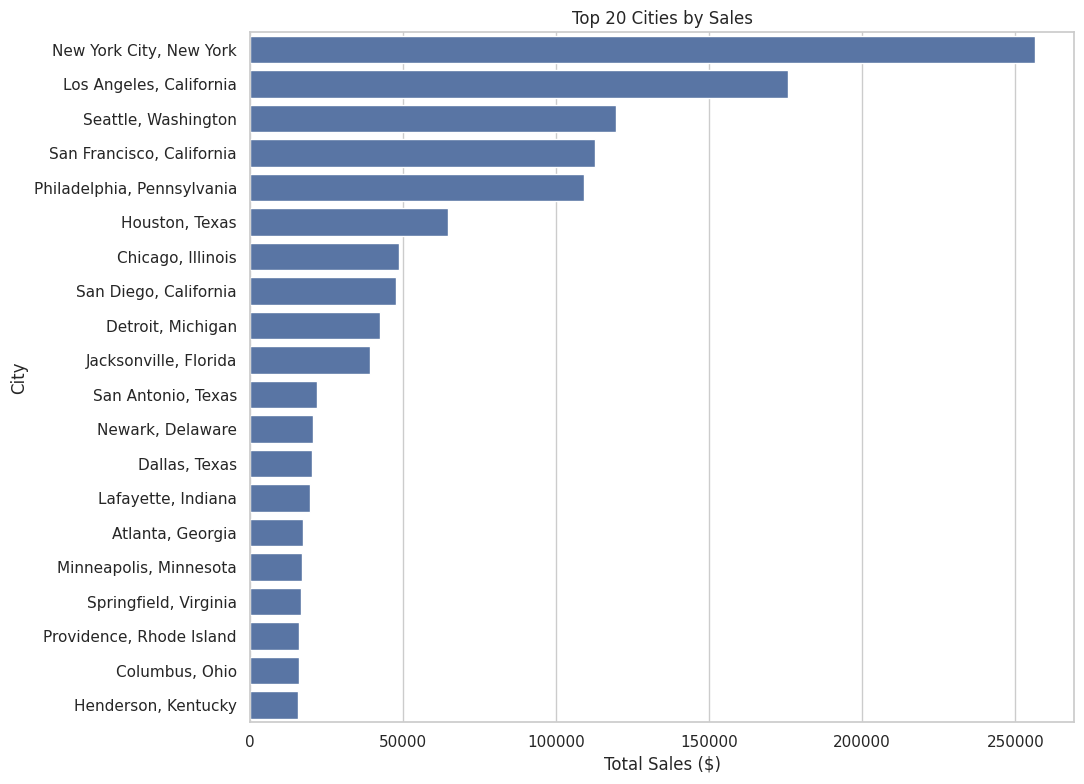

In [50]:
plt.figure(figsize=(11, 8))

sns.barplot(
    data=top_20_cities_sales,
    x="Total_Sales",
    y="City_State"
)

plt.title("Top 20 Cities by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [51]:
top_20_cities_profit = (
    city_performance
    .sort_values("Total_Profit", ascending=False)
    .head(20)
)

top_20_cities_profit[
    [
        "City_State",
        "Total_Sales",
        "Total_Profit",
        "Profit_Margin"
    ]
]

,City_State,Total_Sales,Total_Profit,Profit_Margin
380,"New York City, New York",256368.161,62036.9837,24.198396
312,"Los Angeles, California",175851.341,30440.7579,17.310507
517,"Seattle, Washington",119540.742,29156.0967,24.390092
503,"San Francisco, California",112669.092,17507.3854,15.538765
143,"Detroit, Michigan",42446.944,13181.7908,31.054746
271,"Lafayette, Indiana",19630.450,8976.0973,45.725377
381,"Newark, Delaware",20448.050,8086.1715,39.544952
23,"Atlanta, Georgia",17197.840,6993.6629,40.665938
348,"Minneapolis, Minnesota",16870.540,6824.5846,40.452674
502,"San Diego, California",47521.029,6377.1960,13.419735


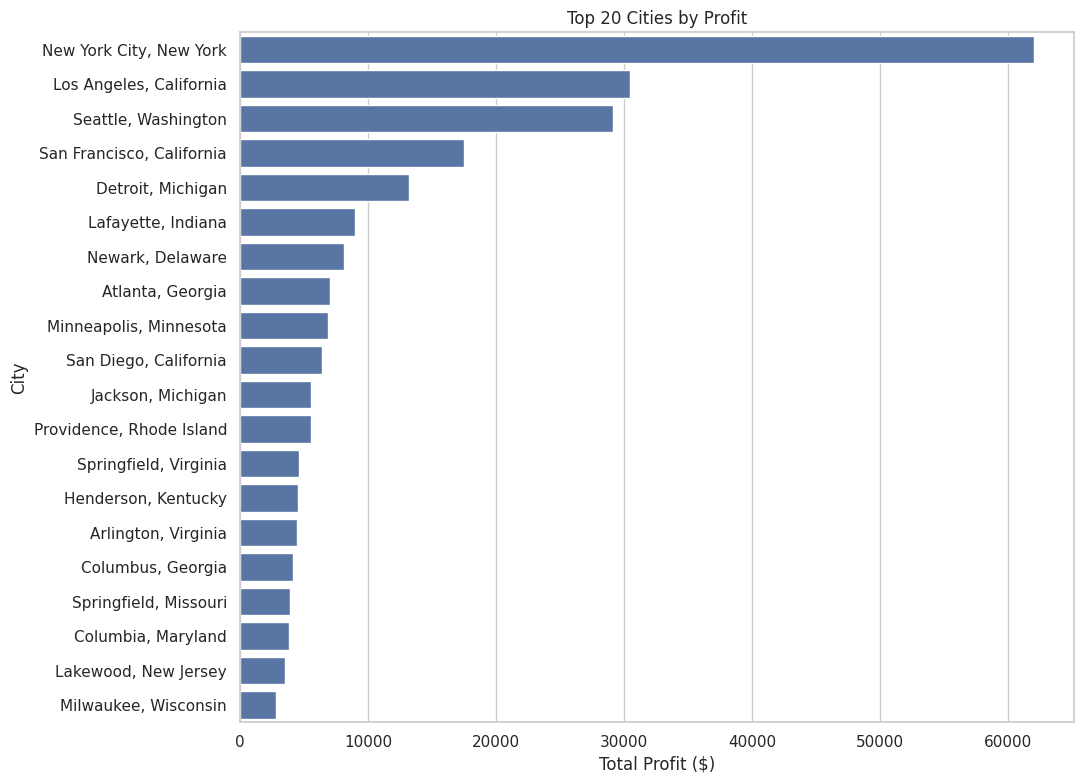

In [52]:
plt.figure(figsize=(11, 8))

sns.barplot(
    data=top_20_cities_profit,
    x="Total_Profit",
    y="City_State"
)

plt.title("Top 20 Cities by Profit")
plt.xlabel("Total Profit ($)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

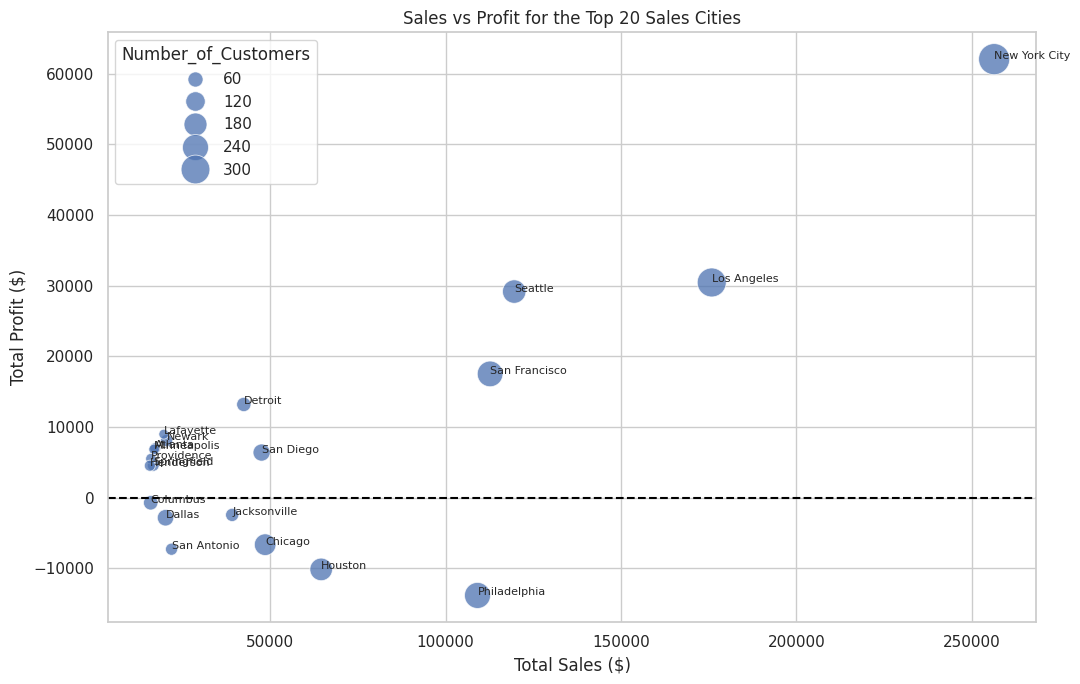

In [53]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=top_20_cities_sales,
    x="Total_Sales",
    y="Total_Profit",
    size="Number_of_Customers",
    sizes=(50, 500),
    alpha=0.75
)

plt.axhline(0, color="black", linestyle="--")

for _, row in top_20_cities_sales.iterrows():
    plt.text(
        row["Total_Sales"],
        row["Total_Profit"],
        row["City"],
        fontsize=8
    )

plt.title("Sales vs Profit for the Top 20 Sales Cities")
plt.xlabel("Total Sales ($)")
plt.ylabel("Total Profit ($)")
plt.tight_layout()
plt.show()

In [54]:
unprofitable_top_sales_cities = top_20_cities_sales[
    top_20_cities_sales["Total_Profit"] < 0
]

unprofitable_top_sales_cities[
    [
        "City_State",
        "Total_Sales",
        "Total_Profit",
        "Profit_Margin"
    ]
]

,City_State,Total_Sales,Total_Profit,Profit_Margin
430,"Philadelphia, Pennsylvania",109077.0130,-13837.7674,-12.686236
239,"Houston, Texas",64504.7604,-10153.5485,-15.740774
90,"Chicago, Illinois",48539.5410,-6654.5688,-13.709583
251,"Jacksonville, Florida",39133.3280,-2445.6608,-6.249560
499,"San Antonio, Texas",21843.5280,-7299.0502,-33.415162
126,"Dallas, Texas",20131.9322,-2846.5257,-14.139357
109,"Columbus, Ohio",15900.7930,-729.5052,-4.587854


Summary of Data:

Cities appearing in both the top-sales and top-profit lists are strong candidates for marketing investment.

Cities with high sales but low or negative profit require investigation before additional marketing spending. The company should examine discounts, product mix and order costs in those locations.

Top 20 Customers by Sales

In [55]:
customer_sales = (
    df.groupby(
        ["Customer ID", "Customer Name"],
        as_index=False
    )
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Number_of_Orders=("Order ID", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
)

top_20_customers_sales = customer_sales.head(20)

top_20_customers_sales

,Customer ID,Customer Name,Total_Sales,Total_Profit,Number_of_Orders,Total_Quantity
700,SM-20320,Sean Miller,25043.050,-1980.7393,5,50
741,TC-20980,Tamara Chand,19052.218,8981.3239,5,42
621,RB-19360,Raymond Buch,15117.339,6976.0959,6,71
730,TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36
6,AB-10105,Adrian Barton,14473.571,5444.8055,10,73
434,KL-16645,Ken Lonsdale,14175.229,806.8550,12,113
669,SC-20095,Sanjit Chand,14142.334,5757.4119,9,87
327,HL-15040,Hunter Lopez,12873.298,5622.4292,6,50
683,SE-20110,Sanjit Engle,12209.438,2650.6769,11,78
131,CC-12370,Christopher Conant,12129.072,2177.0493,5,34


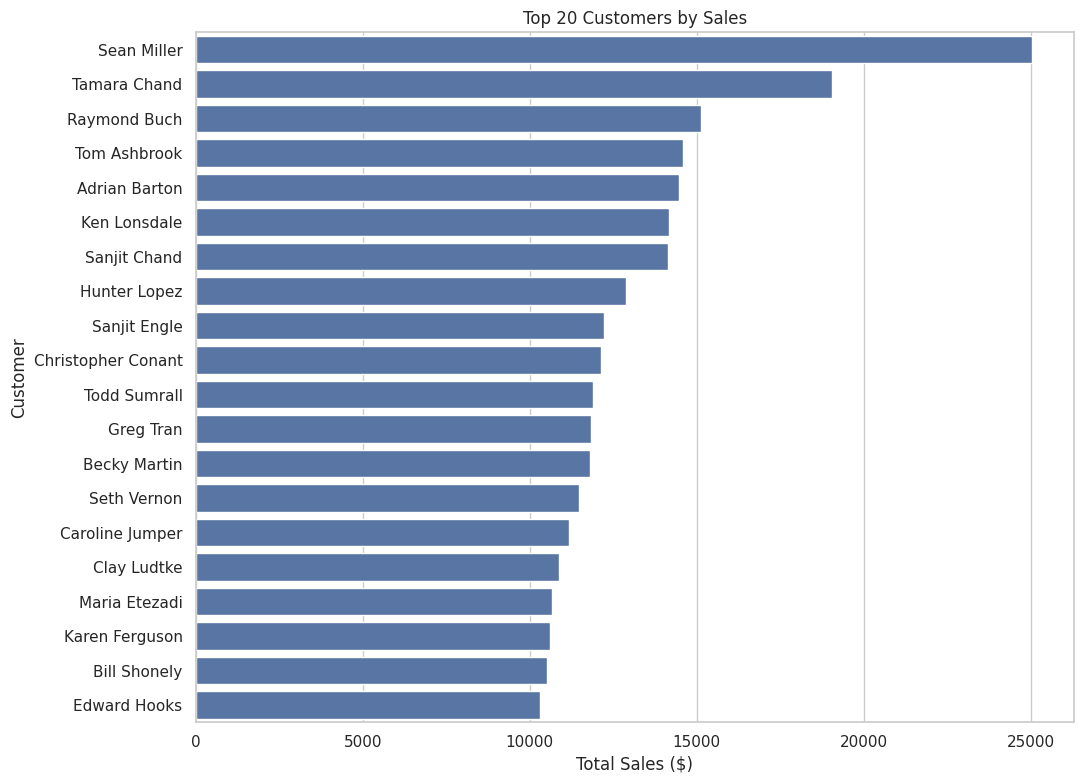

In [56]:
plt.figure(figsize=(11, 8))

sns.barplot(
    data=top_20_customers_sales,
    x="Total_Sales",
    y="Customer Name"
)

plt.title("Top 20 Customers by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

In [57]:
top_20_customers_sales[
    [
        "Customer Name",
        "Total_Sales",
        "Total_Profit",
        "Number_of_Orders"
    ]
].style.format({
    "Total_Sales": "${:,.2f}",
    "Total_Profit": "${:,.2f}"
})

,Customer Name,Total_Sales,Total_Profit,Number_of_Orders
700,Sean Miller,"$25,043.05","$-1,980.74",5
741,Tamara Chand,"$19,052.22","$8,981.32",5
621,Raymond Buch,"$15,117.34","$6,976.10",6
730,Tom Ashbrook,"$14,595.62","$4,703.79",4
6,Adrian Barton,"$14,473.57","$5,444.81",10
434,Ken Lonsdale,"$14,175.23",$806.85,12
669,Sanjit Chand,"$14,142.33","$5,757.41",9
327,Hunter Lopez,"$12,873.30","$5,622.43",6
683,Sanjit Engle,"$12,209.44","$2,650.68",11
131,Christopher Conant,"$12,129.07","$2,177.05",5


Cumulative Sales Curve by Customers

In [58]:
customer_sales_curve = (
    customer_sales
    .sort_values("Total_Sales", ascending=False)
    .reset_index(drop=True)
)

customer_sales_curve["Cumulative_Sales"] = (
    customer_sales_curve["Total_Sales"].cumsum()
)

customer_sales_curve["Cumulative_Sales_Percentage"] = (
    customer_sales_curve["Cumulative_Sales"] /
    customer_sales_curve["Total_Sales"].sum() * 100
)

customer_sales_curve["Customer_Percentage"] = (
    np.arange(1, len(customer_sales_curve) + 1) /
    len(customer_sales_curve) * 100
)

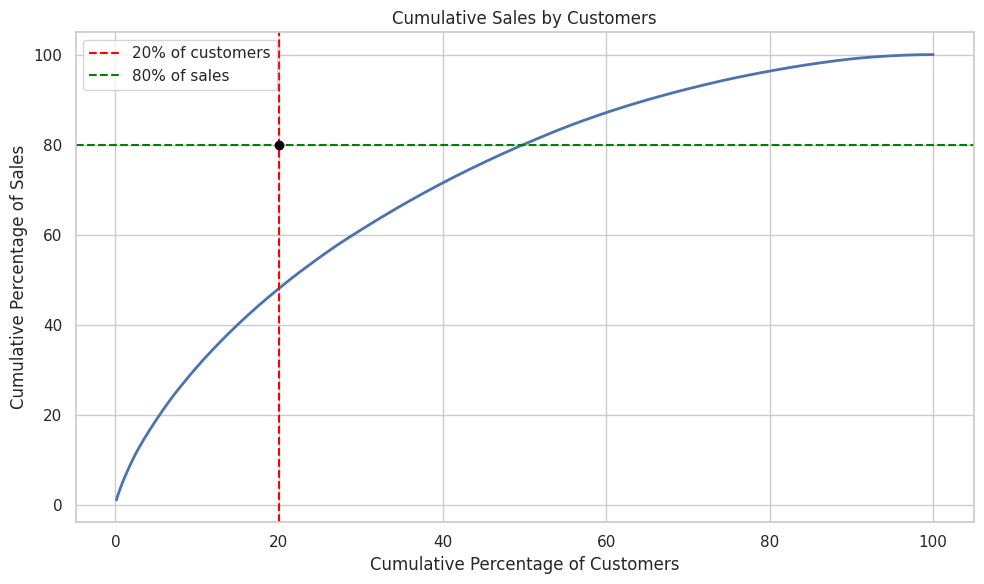

In [59]:
plt.figure(figsize=(10, 6))

plt.plot(
    customer_sales_curve["Customer_Percentage"],
    customer_sales_curve["Cumulative_Sales_Percentage"],
    linewidth=2
)

plt.axvline(
    20,
    color="red",
    linestyle="--",
    label="20% of customers"
)

plt.axhline(
    80,
    color="green",
    linestyle="--",
    label="80% of sales"
)

plt.scatter(
    20,
    80,
    color="black",
    zorder=5
)

plt.title("Cumulative Sales by Customers")
plt.xlabel("Cumulative Percentage of Customers")
plt.ylabel("Cumulative Percentage of Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
top_20_count_sales = int(
    np.ceil(len(customer_sales_curve) * 0.20)
)

top_20_sales_share = (
    customer_sales_curve
    .head(top_20_count_sales)["Total_Sales"]
    .sum() /
    customer_sales_curve["Total_Sales"].sum() * 100
)

print(
    f"The top 20% of customers generate "
    f"{top_20_sales_share:.2f}% of total sales."
)

The top 20% of customers generate 48.15% of total sales.


In [61]:
customers_to_80_sales = (
    customer_sales_curve[
        customer_sales_curve["Cumulative_Sales_Percentage"] >= 80
    ]
    .iloc[0]
)

print(
    f"It takes approximately "
    f"{customers_to_80_sales['Customer_Percentage']:.2f}% "
    f"of customers to generate 80% of sales."
)

It takes approximately 49.94% of customers to generate 80% of sales.


In [62]:
if top_20_sales_share >= 80:
    print("The Pareto Principle applies to customer sales.")
else:
    print("The exact 80/20 rule does not apply to customer sales.")
    print("Sales may still be concentrated among the highest-value customers.")

The exact 80/20 rule does not apply to customer sales.
Sales may still be concentrated among the highest-value customers.


Analyze Sales and Profit Over Time

In [63]:
monthly_performance = (
    df.groupby("Year-Month", as_index=False)
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

monthly_performance["Year-Month-Date"] = pd.to_datetime(
    monthly_performance["Year-Month"]
)

monthly_performance = monthly_performance.sort_values(
    "Year-Month-Date"
)

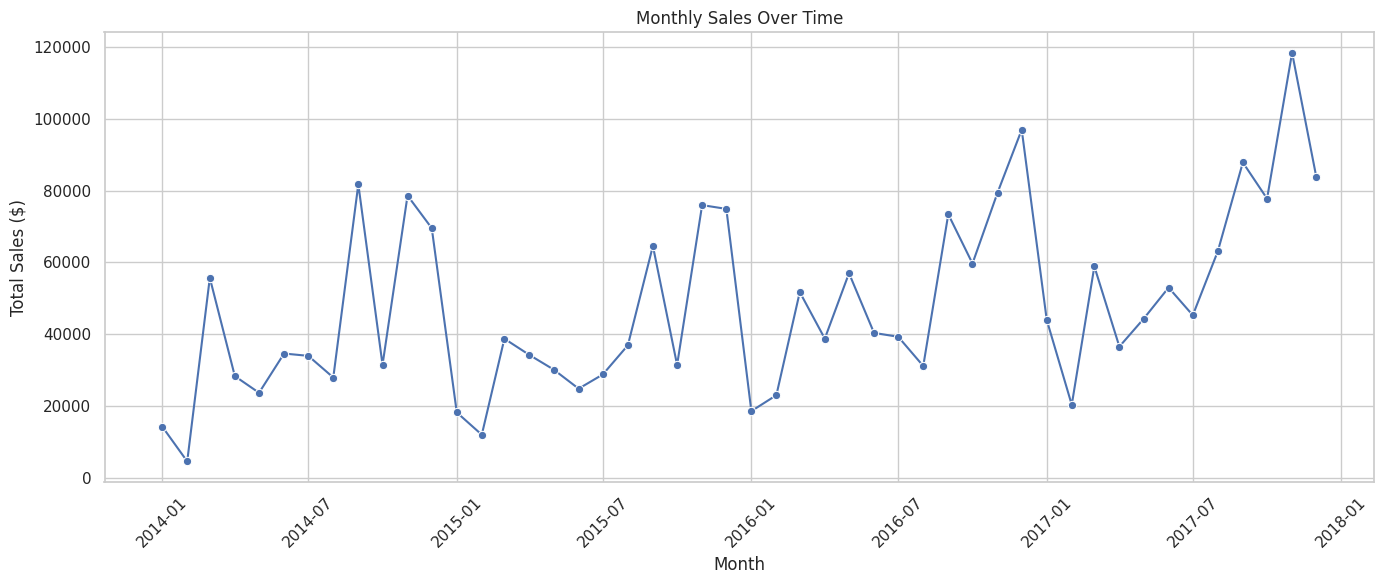

In [64]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_performance,
    x="Year-Month-Date",
    y="Total_Sales",
    marker="o"
)

plt.title("Monthly Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

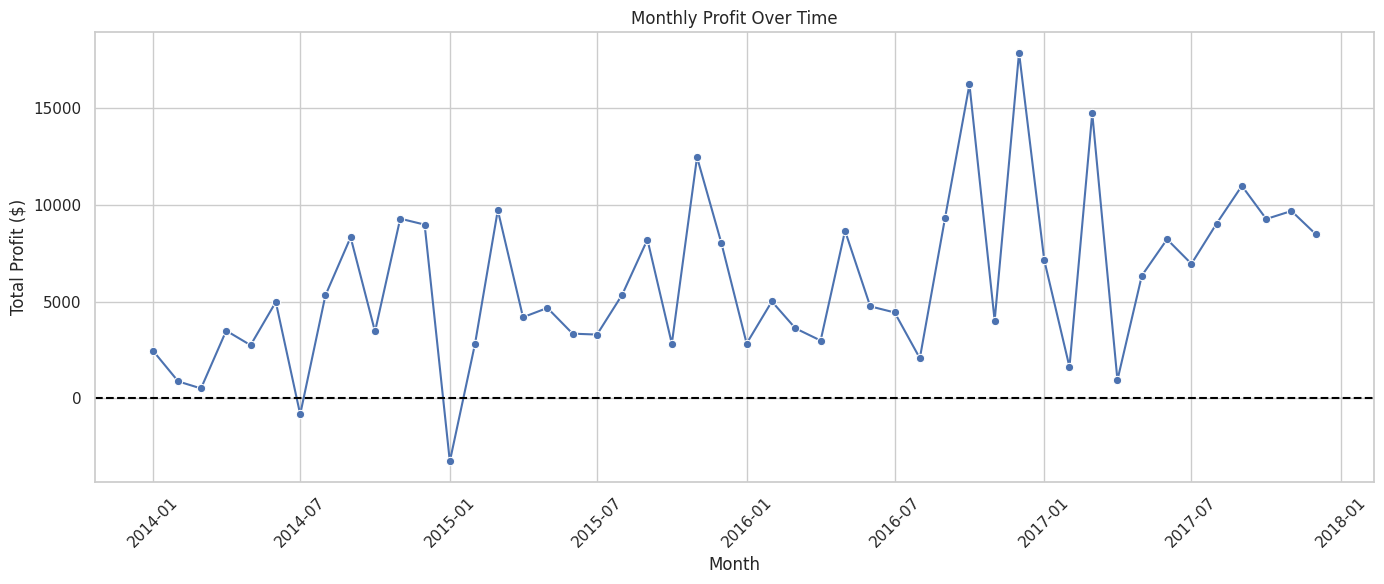

In [65]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_performance,
    x="Year-Month-Date",
    y="Total_Profit",
    marker="o"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Monthly Profit Over Time")
plt.xlabel("Month")
plt.ylabel("Total Profit ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Automatic Marketing-Priority Table

In [66]:
state_strategy = state_profitability.copy()

sales_median = state_strategy["Total_Sales"].median()
profit_median = state_strategy["Total_Profit"].median()

conditions = [
    (
        (state_strategy["Total_Sales"] >= sales_median) &
        (state_strategy["Total_Profit"] >= profit_median)
    ),
    (
        (state_strategy["Total_Sales"] >= sales_median) &
        (state_strategy["Total_Profit"] < profit_median)
    ),
    (
        (state_strategy["Total_Sales"] < sales_median) &
        (state_strategy["Total_Profit"] >= profit_median)
    )
]

choices = [
    "Priority Market",
    "Improve Profitability",
    "Growth Opportunity"
]

state_strategy["Marketing_Strategy"] = np.select(
    conditions,
    choices,
    default="Low Priority"
)

state_strategy.sort_values(
    ["Marketing_Strategy", "Total_Sales"],
    ascending=[True, False]
)

,State,Total_Sales,Total_Profit,Profit_Margin,Marketing_Strategy
34,Oklahoma,19683.3900,4853.9560,24.660163,Growth Opportunity
0,Alabama,19510.6400,5786.8253,29.659844,Growth Opportunity
26,Nevada,16729.1020,3316.7659,19.826324,Growth Opportunity
5,Connecticut,13384.3570,3511.4918,26.235790,Growth Opportunity
2,Arkansas,11678.1300,4008.6871,34.326447,Growth Opportunity
42,Utah,11220.0560,2546.5335,22.696264,Growth Opportunity
22,Mississippi,10771.3400,3172.9762,29.457581,Growth Opportunity
16,Louisiana,9217.0300,2196.1023,23.826572,Growth Opportunity
43,Vermont,8929.3700,2244.9783,25.141508,Growth Opportunity
41,Texas,170188.0458,-25729.3563,-15.118192,Improve Profitability


In [67]:
priority_states = (
    state_strategy[
        state_strategy["Marketing_Strategy"] == "Priority Market"
    ]
    .sort_values("Total_Profit", ascending=False)
)

priority_states[
    [
        "State",
        "Total_Sales",
        "Total_Profit",
        "Profit_Margin",
        "Marketing_Strategy"
    ]
]

,State,Total_Sales,Total_Profit,Profit_Margin,Marketing_Strategy
3,California,457687.6315,76381.3871,16.688541,Priority Market
30,New York,310876.2710,74038.5486,23.816082,Priority Market
45,Washington,138641.2700,33402.6517,24.092863,Priority Market
20,Michigan,76269.6140,24463.1876,32.074618,Priority Market
44,Virginia,70636.7200,18597.9504,26.329012,Priority Market
12,Indiana,53555.3600,18382.9363,34.325110,Priority Market
9,Georgia,49095.8400,16250.0433,33.098615,Priority Market
15,Kentucky,36591.7500,11199.6966,30.607163,Priority Market
21,Minnesota,29863.1500,10823.1874,36.242618,Priority Market
6,Delaware,27451.0690,9977.3748,36.346034,Priority Market


In [68]:
city_strategy = city_performance.copy()

city_sales_median = city_strategy["Total_Sales"].median()
city_profit_median = city_strategy["Total_Profit"].median()

city_conditions = [
    (
        (city_strategy["Total_Sales"] >= city_sales_median) &
        (city_strategy["Total_Profit"] >= city_profit_median)
    ),
    (
        (city_strategy["Total_Sales"] >= city_sales_median) &
        (city_strategy["Total_Profit"] < city_profit_median)
    ),
    (
        (city_strategy["Total_Sales"] < city_sales_median) &
        (city_strategy["Total_Profit"] >= city_profit_median)
    )
]

city_strategy["Marketing_Strategy"] = np.select(
    city_conditions,
    choices,
    default="Low Priority"
)

priority_cities = (
    city_strategy[
        city_strategy["Marketing_Strategy"] == "Priority Market"
    ]
    .sort_values("Total_Profit", ascending=False)
    .head(20)
)

priority_cities[
    [
        "City_State",
        "Total_Sales",
        "Total_Profit",
        "Profit_Margin",
        "Marketing_Strategy"
    ]
]

,City_State,Total_Sales,Total_Profit,Profit_Margin,Marketing_Strategy
380,"New York City, New York",256368.161,62036.9837,24.198396,Priority Market
312,"Los Angeles, California",175851.341,30440.7579,17.310507,Priority Market
517,"Seattle, Washington",119540.742,29156.0967,24.390092,Priority Market
503,"San Francisco, California",112669.092,17507.3854,15.538765,Priority Market
143,"Detroit, Michigan",42446.944,13181.7908,31.054746,Priority Market
271,"Lafayette, Indiana",19630.450,8976.0973,45.725377,Priority Market
381,"Newark, Delaware",20448.050,8086.1715,39.544952,Priority Market
23,"Atlanta, Georgia",17197.840,6993.6629,40.665938,Priority Market
348,"Minneapolis, Minnesota",16870.540,6824.5846,40.452674,Priority Market
502,"San Diego, California",47521.029,6377.1960,13.419735,Priority Market


Marketing Strategy Conclusions

The state analysis shows that California and New York generate the highest total sales. These states represent the company’s largest existing markets and should remain important parts of the marketing strategy.

California generated nearly $458,000 in sales and $76,000 in profit, while New York generated nearly $311,000 in sales and $74,000 in profit. Although California had higher sales, New York had the stronger profit margin. This shows that sales volume alone does not fully measure market quality.

In New York, Tom Ashbrook was the leading customer by sales and profit. He should be considered for loyalty programs, personalized offers or dedicated account management.

Profitability differed considerably across states. Some states produced strong sales but low or negative profit. Marketing investment in those states should be limited until the company reviews discounts, shipping costs and unprofitable product categories.

The top 20% of customers generated 59% of sales and 64% of profit. The exact 80/20 rule does not apply to customer profit. However, profit may still be concentrated among a relatively small group.

The strongest cities were those appearing near the top of both the sales and profit rankings, including Atlanta and Minneapolis. These cities should receive customer-retention campaigns and increased marketing investment. Cities with high sales but weak profit should be reviewed before receiving additional advertising.

Overall, the company should prioritize:

States and cities with both high sales and high profit.
Retention programs for the highest-value customers.
Growth campaigns in profitable but underdeveloped markets.
Reduced discounting and profitability reviews in high-sales, low-profit markets.
Seasonal campaigns during months that historically produce the strongest sales and profits.